# Interfacing pytorch models with collections of AnnData objects via `annbatch`

**Author:** [Sergei Rybakov](https://github.com/koncopd)
**Author:** [Ilan Gold](https://github.com/ilan-gold)

* This tutorial uses `annbatch.Loader` to interface pytorch models, aimed at training models at the scale of many AnnData objects.
* Install `annbatch` for in-memory sparse data via `pip install "annbatch[numba]"` - note that the `numba` extra is required for in-memory data

In [89]:
import gdown
import torch
import torch.nn as nn
import pyro
import pyro.distributions as dist
import numpy as np
import scanpy as sc
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from annbatch import Loader
import anndata as ad
pyro.clear_param_store()

## VAE model definition

In [2]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, out_dim):
        super().__init__()
        
        modules = []
        for in_size, out_size in zip([input_dim]+hidden_dims, hidden_dims):
            modules.append(nn.Linear(in_size, out_size))
            modules.append(nn.LayerNorm(out_size))
            modules.append(nn.ReLU())
            modules.append(nn.Dropout(p=0.05))
        modules.append(nn.Linear(hidden_dims[-1], out_dim))
        self.fc = nn.Sequential(*modules)
    
    def forward(self, *inputs):
        shape = dist.util.broadcast_shape(*[s.shape[:-1] for s in inputs]) + (-1,)
        inputs = [s.expand(shape) for s in inputs]
        
        input_cat = torch.cat(inputs, dim=-1)
        return self.fc(input_cat)

This model is a bit different from the model in the AnnLoader tutorial. Here the counts variable `X` depends on the class labels `Class` not only through the latent variable `Z` but also directly.This makes this model semi-supervised. 

<img src="./_static/semisup_cvae.jpg" width="200px">

In [3]:
# The code is based on the scarches trvae model
# https://github.com/theislab/scarches/blob/v0.3.5/scarches/models/trvae/trvae.py
# and on the pyro.ai Variational Autoencoders tutorial
# http://pyro.ai/examples/vae.html
# and the Semi-Supervised VAE tutorial
# http://pyro.ai/examples/ss-vae.html
class CVAE(nn.Module):
    def __init__(self, input_dim, n_conds, n_classes, hidden_dims, latent_dim, classifier_dims=[128]):
        super().__init__()
        
        self.encoder = MLP(input_dim+n_conds, hidden_dims, 2*latent_dim) # output - mean and logvar of z
        
        self.decoder = MLP(latent_dim+n_conds+n_classes, hidden_dims[::-1], input_dim)
        self.theta = nn.Linear(n_conds, input_dim, bias=False)
        
        self.classifier = MLP(latent_dim, classifier_dims, n_classes)
        
        self.latent_dim = latent_dim
    
    def model(self, x, batches, classes, size_factors, supervised):
        pyro.module("cvae", self)
        
        batch_size = x.shape[0]
        
        with pyro.plate("data", batch_size):
            z_loc = x.new_zeros((batch_size, self.latent_dim))
            z_scale = x.new_ones((batch_size, self.latent_dim))
            z = pyro.sample("Z", dist.Normal(z_loc, z_scale).to_event(1))
            
            classes_probs = self.classifier(z).softmax(dim=-1)
            if supervised:
                obs = classes
            else:
                obs = None
            classes = pyro.sample("Class", dist.OneHotCategorical(probs=classes_probs), obs=obs)
            
            dec_mu = self.decoder(z, batches, classes).softmax(dim=-1) * size_factors[:, None]
            dec_theta = torch.exp(self.theta(batches))
            
            logits = (dec_mu + 1e-6).log() - (dec_theta + 1e-6).log()
            
            pyro.sample("X", dist.NegativeBinomial(total_count=dec_theta, logits=logits).to_event(1), obs=x.int())
        
    def guide(self, x, batches, classes, size_factors, supervised):
        batch_size = x.shape[0]
        
        with pyro.plate("data", batch_size):
            z_loc_scale = self.encoder(x, batches)
            
            z_mu = z_loc_scale[:, :self.latent_dim]
            z_var = torch.sqrt(torch.exp(z_loc_scale[:, self.latent_dim:]) + 1e-4)
            
            z = pyro.sample("Z", dist.Normal(z_mu, z_var).to_event(1))
            
            if not supervised:
                classes_probs = self.classifier(z).softmax(dim=-1)
                pyro.sample("Class", dist.OneHotCategorical(probs=classes_probs))

## Create AnnCollection from two AnnData objects

The data is from this [scvi reproducibility notebook](https://yoseflab.github.io/scvi-tools-reproducibility/scarches_totalvi_seurat_data/).

In [4]:
# Run this if you need the data
# gdown.download(url="https://drive.google.com/uc?id=1X5N9rOaIqiGxZRyr1fyZ6NpDPeATXoaC", 
#                output="pbmc_seurat_v4.h5ad", quiet=False)
# gdown.download(url="https://drive.google.com/uc?id=1JgaXNwNeoEqX7zJL-jJD3cfXDGurMrq9", 
#                output="covid_cite.h5ad", quiet=False)

In [6]:
covid = sc.read('covid_cite.h5ad')
pbmc = sc.read('pbmc_seurat_v4.h5ad')

In [7]:
covid

AnnData object with n_obs × n_vars = 57669 × 33538
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'RNA_snn_res.0.4', 'seurat_clusters', 'set', 'Resp', 'disease', 'subj_code', 'covidpt_orhealth', 'mito', 'ncount', 'nfeat', 'bust_21', 'og_clust', 'severmod_other', 'og_clusts', 'nCount_ADT', 'nFeature_ADT', 'UMAP1', 'UMAP2', 'final_clust', 'final_clust_v2', 'new_pt_id', 'Resp_og', 'final_clust_withnum', 'final_clust_review', 'Age', 'Gender', 'Gender_num'
    obsm: 'pro_exp'

In [8]:
pbmc

AnnData object with n_obs × n_vars = 161764 × 20729
    obs: 'nCount_ADT', 'nFeature_ADT', 'nCount_RNA', 'nFeature_RNA', 'orig.ident', 'lane', 'donor', 'time', 'celltype.l1', 'celltype.l2', 'celltype.l3', 'Phase', 'nCount_SCT', 'nFeature_SCT', 'X_index'
    obsm: 'protein_counts'

In [9]:
covid.obs['size_factors'] = np.asarray(covid.X.sum(1)).ravel()
pbmc.obs['size_factors'] = np.asarray(pbmc.X.sum(1)).ravel()

In [10]:
sc.pp.highly_variable_genes(
    pbmc,
    n_top_genes=4000,
    flavor="seurat_v3",
    batch_key="orig.ident",
    subset=True,
)

In [11]:
covid

AnnData object with n_obs × n_vars = 57669 × 33538
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'RNA_snn_res.0.4', 'seurat_clusters', 'set', 'Resp', 'disease', 'subj_code', 'covidpt_orhealth', 'mito', 'ncount', 'nfeat', 'bust_21', 'og_clust', 'severmod_other', 'og_clusts', 'nCount_ADT', 'nFeature_ADT', 'UMAP1', 'UMAP2', 'final_clust', 'final_clust_v2', 'new_pt_id', 'Resp_og', 'final_clust_withnum', 'final_clust_review', 'Age', 'Gender', 'Gender_num', 'size_factors'
    obsm: 'pro_exp'

In [12]:
pbmc

AnnData object with n_obs × n_vars = 161764 × 4000
    obs: 'nCount_ADT', 'nFeature_ADT', 'nCount_RNA', 'nFeature_RNA', 'orig.ident', 'lane', 'donor', 'time', 'celltype.l1', 'celltype.l2', 'celltype.l3', 'Phase', 'nCount_SCT', 'nFeature_SCT', 'X_index', 'size_factors'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'hvg'
    obsm: 'protein_counts'

In [13]:
dataset = ad.concat(
    {'covid': covid, 'pbmc':pbmc},
    join='inner',
    label='dataset',
)

In [14]:
dataset

AnnData object with n_obs × n_vars = 219433 × 4000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_ADT', 'nFeature_ADT', 'size_factors', 'dataset'

In [15]:
dataset.obs['orig.ident'] = dataset.obs['orig.ident'].astype(str)
dataset.obs.loc[covid.obs_names, 'orig.ident'] = covid.obs['set']
dataset.obs['orig.ident'] = dataset.obs['orig.ident'].astype("category")

In [16]:
dataset.obs['size_factors'] = dataset.X.sum(1)

In [17]:
labels = 'celltype.l1'

In [18]:
dataset.obs[labels] = pd.concat([pd.Series(index=covid.obs_names, data=["not-annotated"] * covid.shape[0]), pbmc.obs["celltype.l1"].astype("str")]).astype("category")

In [19]:
dataset.obs[labels]

AAACCCACACCAGCGT-1       not-annotated
AAACCCACATCTCAAG-1       not-annotated
AAACGAAAGACCTGGA-1       not-annotated
AAACGCTCAGTGGGTA-1       not-annotated
AAACGCTGTAGCTTGT-1       not-annotated
                             ...      
E2L8_TTTGTTGGTCGTGATT            CD8 T
E2L8_TTTGTTGGTGTGCCTG             Mono
E2L8_TTTGTTGGTTAGTTCG                B
E2L8_TTTGTTGGTTGGCTAT             Mono
E2L8_TTTGTTGTCTCATGGA             Mono
Name: celltype.l1, Length: 219433, dtype: category
Categories (9, object): ['B', 'CD4 T', 'CD8 T', 'DC', ..., 'NK', 'not-annotated', 'other', 'other T']

In [20]:
use_cuda = torch.cuda.is_available()
use_cuda

True

In [21]:
encoder_study = OneHotEncoder(sparse_output=False, dtype=np.float32)
encoder_study.fit(dataset.obs['orig.ident'].to_numpy()[: , None])

encoder_celltype = OneHotEncoder(sparse_output=False, dtype=np.float32)
encoder_celltype.fit(pbmc.obs[labels].to_numpy()[: , None])

,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float32'>
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'error'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide <encoder_infrequen

## Loader and model initialization

We'll initialize a loader from the concatenated dataset. This is a larger batch size than you might be used to but lets the notebook run much quicker at no appreciable difference in performance compared to a previous version over 250 epochs (loss / umaps).

In [58]:
loader = Loader(chunk_size=1, preload_nchunks=8192, batch_size=8192, shuffle=True, preload_to_gpu=True).add_adata(dataset)

In [59]:
pyro.clear_param_store()
torch.set_float32_matmul_precision("high")

n_conds = len(dataset.obs["orig.ident"].values.categories)
n_classes = len(dataset.obs[labels].values.categories) - 1

latent_dim = 20

cvae = CVAE(dataset.shape[1], n_conds=n_conds, n_classes=n_classes, hidden_dims=[1280, 256], latent_dim=latent_dim)

if use_cuda:
    cvae.cuda()

## Train the model

In [60]:
optimizer = pyro.optim.Adam({"lr": 1e-3})

svi_sup = pyro.infer.SVI(cvae.model, cvae.guide, 
                         optimizer, loss=pyro.infer.TraceMeanField_ELBO())

# very slow for sequential
svi_unsup = pyro.infer.SVI(cvae.model, pyro.infer.config_enumerate(cvae.guide, 'parallel', expand=True), 
                           optimizer, loss=pyro.infer.TraceEnum_ELBO())

In [61]:


def train(svi_sup, svi_unsup, train_loader):
    epoch_loss = 0.
    num_correct = 0
    for batch in train_loader:
        # select indices of labelled cells
        sup_idx = (batch["obs"]["dataset"] == "pbmc").to_numpy()
        X = batch["X"].to_dense().int()
        cols = ['orig.ident', labels, 'size_factors']
        obs_dict = batch["obs"][cols].to_dict("series")
        obs_dict['size_factors'] = torch.Tensor(obs_dict['size_factors'].to_numpy()).cuda()
        obs_dict['orig.ident'] = torch.Tensor(encoder_study.transform(obs_dict['orig.ident'].to_numpy()[: , None])).cuda()
        # do supervised step for the labelled cells
        sup_data = {
            "orig.ident": obs_dict["orig.ident"][sup_idx],
            labels: torch.Tensor(
                encoder_celltype.transform(
                    obs_dict[labels].loc[sup_idx].to_numpy()[:, None]
                )
            ).cuda(),
            "size_factors": obs_dict["size_factors"][sup_idx],
        }

        sup_data['supervised'] = True
        epoch_loss += svi_sup.step(X[sup_idx], *sup_data.values())
        
        # do unsupervised step for unlabelled cells
        unsup_data = {
            "orig.ident": obs_dict["orig.ident"][~sup_idx],
            labels: torch.empty(((~sup_idx).sum(), n_classes)).cuda(),
            "size_factors": obs_dict["size_factors"][~sup_idx],
        }

        unsup_data['supervised'] = False
        epoch_loss += svi_unsup.step(X[~sup_idx], *unsup_data.values())
    normalizer_train = train_loader.n_obs
    total_epoch_loss_train = epoch_loss / normalizer_train
    return total_epoch_loss_train

In [62]:
NUM_EPOCHS = 250

for epoch in range(NUM_EPOCHS):
    total_epoch_loss_train = train(svi_sup, svi_unsup, loader)
    if epoch % 40 == 0 or epoch == NUM_EPOCHS-1:
        print("[epoch %03d]  average training loss: %.4f" % (epoch, total_epoch_loss_train))

[epoch 000]  average training loss: 1255.0783
[epoch 040]  average training loss: 919.0868
[epoch 080]  average training loss: 903.4886
[epoch 120]  average training loss: 898.2071
[epoch 160]  average training loss: 895.3621
[epoch 200]  average training loss: 894.0363
[epoch 240]  average training loss: 893.1848
[epoch 249]  average training loss: 893.0040


## Check the results

Get means of latent variables and cell labels predictions for the unlabelled data.

In [71]:
batch["index"]

array([   0,    1,    2, ..., 8189, 8190, 8191], shape=(8192,))

In [78]:
dataset.obsm['X_cvae'] = np.empty((dataset.shape[0], latent_dim), dtype='float32')
dataset.obs['cell_type_pred'] = pd.Series(dtype=pbmc.obs[labels].dtype)
loader = Loader(chunk_size=512, preload_nchunks=8192, batch_size=8192, shuffle=False, preload_to_gpu=True, return_index=True).add_adata(dataset)

for batch in loader:
    latents = cvae.encoder(batch["X"].to_dense(), torch.Tensor(encoder_study.transform(batch["obs"]['orig.ident'].to_numpy()[: , None])).cuda())[:, :latent_dim].detach()
    
    predict = cvae.classifier(latents).detach()
    one_hot = torch.zeros(predict.shape[0], predict.shape[1], device=predict.device)
    one_hot = one_hot.scatter_(1, predict.argmax(dim=-1, keepdim=True) , 1.).cpu().numpy()
    
    dataset.obsm['X_cvae'][batch["index"]] = latents.cpu().numpy()
    dataset.obs.iloc[batch["index"], 8] = np.ravel(encoder_celltype.inverse_transform(one_hot))

In [79]:
dataset.obs['cell_type_joint'] = dataset.obs['cell_type_pred']
dataset.obs.loc[pbmc.obs_names, 'cell_type_joint']=pbmc.obs[labels]

In [81]:
sc.pp.neighbors(dataset, use_rep='X_cvae')
sc.tl.umap(dataset)

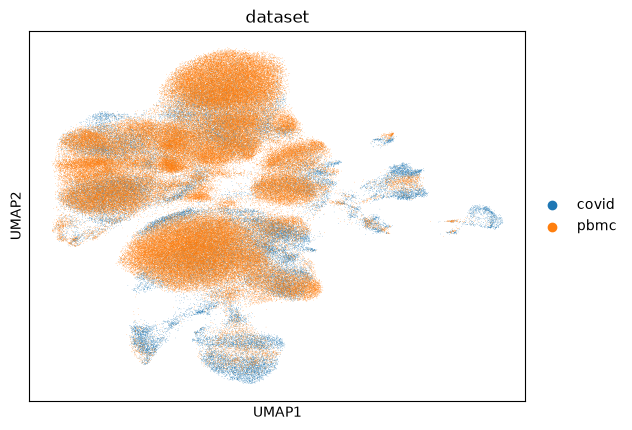

In [83]:
sc.pl.umap(dataset, color=['dataset'])

In [84]:
accuracy = (dataset.obs['cell_type_pred'].loc[pbmc.obs_names]==pbmc.obs[labels]).sum().item()/pbmc.n_obs

In [85]:
accuracy

0.9397764644791178

Plot pbmc cell types and predicted cell types for covid.

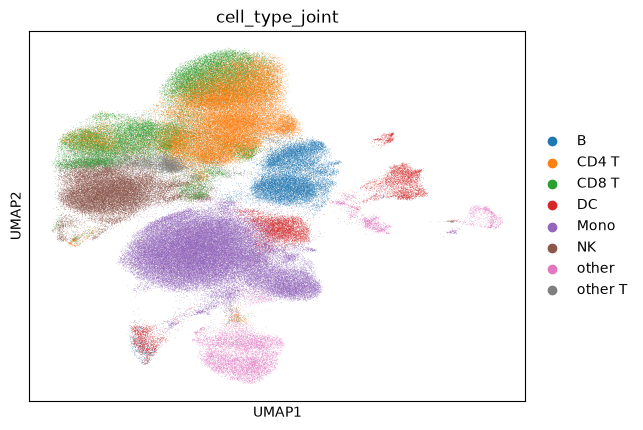

In [87]:
sc.pl.umap(dataset, color='cell_type_joint')